# Experiment 1 — Baseline (No Extra Augmentation)
Mohamed Fahmi Ahmed 

Baseline experiment: EfficientNetV2-S with preprocessor pipeline only.

Key design choices backed by:
- Tan & Le (2021) EfficientNetV2 — ICML
- Rahmadhani et al. (2025) EfficientNetV2-S transfer learning

## 1 — Imports & Setup

In [1]:
import sys, copy, time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import torch
import torch.nn as nn
import torchvision.transforms as T
from torch.amp import GradScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, average_precision_score,
    f1_score, precision_score, recall_score,
)
from sklearn.preprocessing import label_binarize

root = Path.cwd()
while not (root / 'Pipeline_').exists() and root != root.parent:
    root = root.parent
if str(root) not in sys.path:
    sys.path.insert(0, str(root))

from Pipeline_.preprocessor import WaRPPreprocessor
from Models.efficientnet import EfficientNetV2S

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device  : {DEVICE}')
print(f'PyTorch : {torch.__version__}')

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

Device  : cuda
PyTorch : 2.6.0+cu124


## 2 — Hyperparameters

### Schedule
60 epochs total (20 + 40), following Tan & Le (2021) who recommend 30-60 epochs
with cosine learning rate decay for fine-tuning EfficientNetV2.

### Learning rates
Phase 1 uses a high LR (1e-3) — safe because only 35K head params update.
Phase 2 uses differential LR: backbone gets 10x less than the head.
Rahmadhani et al. (2025) used lr=1e-4 for full fine-tuning of EfficientNetV2-S.

### Label smoothing = 0.1
WaRP-C has 17 visually similar bottle subtypes. Hard targets cause overconfidence.
Muller et al. (2019) showed label smoothing consistently improves calibration.

In [2]:
PHASE1_EPOCHS = 20
PHASE2_EPOCHS = 40
TOTAL_EPOCHS  = PHASE1_EPOCHS + PHASE2_EPOCHS

BATCH_SIZE    = 32
HEAD_LR       = 1e-3
BACKBONE_LR   = 1e-4
WEIGHT_DECAY  = 1e-4
LABEL_SMOOTH  = 0.1
NUM_CLASSES   = 28

print(f'Total epochs : {TOTAL_EPOCHS}  (P1: 1-{PHASE1_EPOCHS} | P2: {PHASE1_EPOCHS+1}-{TOTAL_EPOCHS})')
print(f'Batch size   : {BATCH_SIZE}')
print(f'Head LR      : {HEAD_LR}')
print(f'Backbone LR  : {BACKBONE_LR}  (Phase 2 only)')
print(f'Weight decay : {WEIGHT_DECAY}')
print(f'Label smooth : {LABEL_SMOOTH}')

Total epochs : 60  (P1: 1-20 | P2: 21-60)
Batch size   : 32
Head LR      : 0.001
Backbone LR  : 0.0001  (Phase 2 only)
Weight decay : 0.0001
Label smooth : 0.1


## 3 — Data Pipeline

The WaRPPreprocessor handles:
- **PadToSquare + RandomResizedCrop(224)** — WaRP-C aspect ratios range 0.2-5.2
- **Flips, Rotation, ColorJitter** — simulates conveyor belt variability
- **WeightedRandomSampler** — oversamples rare classes (59x imbalance ratio)
- **Minority augmentation** — stronger aug for 3 most underrepresented classes

Normalisation uses WaRP-C statistics (mean=[0.337,0.344,0.350], std=[0.216,0.209,0.218])
rather than ImageNet stats — EDA showed mean_diff > 0.05 threshold.

In [3]:
pp = WaRPPreprocessor(
    raw_root       = root / 'Dataset/raw/Warp-C',
    processed_root = root / 'Dataset/processed',
    stats_file     = root / 'Dataset/dataset_stats.json',
    batch_size     = BATCH_SIZE,
    num_workers    = 4,
)

pp.prepare()  # run once — skips automatically if already done

train_loader, test_loader = pp.get_loaders(model_type='efficientnet')

CLASS_NAMES = sorted(
    d.name for d in (root / 'Dataset/processed/train').iterdir() if d.is_dir()
)
print(f'Classes       : {len(CLASS_NAMES)}')
print(f'Train batches : {len(train_loader)}')
print(f'Test  batches : {len(test_loader)}')

  WaRPPreprocessor.prepare()
  /home/momo/Documents/Semester 2/Applied machine learning/coursework/Waste-Classification/Dataset/processed/ already exists. Pass force=True to recreate.
[get_loaders] model='efficientnet'
  sampler=True  minority_aug=True  mixup=False  pipeline='pretrained_cnn'
  train=273 batches  test=49 batches  sampler=WeightedRandom
Classes       : 28
Train batches : 273
Test  batches : 49


## 4 — Loss Functions

**Phase 1** — CrossEntropyLoss with class weights + label smoothing.
The head starts from random weights and needs a strong imbalance signal.

**Phase 2** — CrossEntropyLoss with label smoothing only.
WeightedRandomSampler already handles imbalance — adding class weights on top
double-penalises majority classes and hurts discrimination between similar categories.

In [4]:
class_weights = pp.get_class_weights(device=DEVICE)

loss_p1 = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=LABEL_SMOOTH)
loss_p2 = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTH)

active_loss = loss_p1
print('Phase 1 loss : CrossEntropyLoss(class_weights + label_smoothing=0.1)')
print('Phase 2 loss : CrossEntropyLoss(label_smoothing=0.1)')

Phase 1 loss : CrossEntropyLoss(class_weights + label_smoothing=0.1)
Phase 2 loss : CrossEntropyLoss(label_smoothing=0.1)


## 5 — EMA (Exponential Moving Average)

EMA maintains a smoothed copy of model weights updated after every batch:

ema_w = decay x ema_w + (1 - decay) x current_w

Part of the official EfficientNetV2 recipe (Tan & Le, 2021). With decay=0.9999
the EMA integrates ~10000 past steps, filtering out noisy gradient fluctuations
from rare-class batches (WaRP-C has a 59x imbalance ratio).

We always evaluate and save using the EMA model.

In [5]:
class ModelEMA:
    def __init__(self, model, decay=0.9999):
        self.shadow = copy.deepcopy(model).eval()
        self.decay  = decay
        for p in self.shadow.parameters():
            p.requires_grad_(False)

    @torch.no_grad()
    def update(self, model):
        for s, m in zip(self.shadow.parameters(), model.parameters()):
            s.mul_(self.decay).add_(m.data, alpha=1.0 - self.decay)

    def accuracy(self, loader, device):
        self.shadow.eval()
        correct = total = 0
        with torch.no_grad():
            for imgs, lbls in loader:
                pred     = self.shadow(imgs.to(device)).argmax(1).cpu()
                correct += (pred == lbls).sum().item()
                total   += lbls.size(0)
        return correct / total * 100

print('ModelEMA defined')

ModelEMA defined


## 6 — Model

EfficientNetV2-S with the ImageNet head (Linear 1280->1000) replaced
by a new head for WaRP-C (Linear 1280->28).

Rahmadhani et al. (2025) used this exact approach — load EfficientNetV2-S
pretrained on ImageNet, replace the final fully connected layer, and fine-tune.

Dropout=0.3 before the linear layer provides regularisation appropriate for
the ~9000 image training set.

In [6]:
model = EfficientNetV2S(num_classes=NUM_CLASSES, dropout=0.3).to(DEVICE)
ema   = ModelEMA(model, decay=0.9999)

with torch.no_grad():
    out = model(torch.zeros(2, 3, 224, 224, device=DEVICE))
print(f'Output shape : {out.shape}  <- expected (2, {NUM_CLASSES})')
print(f'Params       : {model.parameter_counts()}')

Output shape : torch.Size([2, 28])  <- expected (2, 28)
Params       : {'total': 20213356, 'backbone': 20177488, 'head': 35868, 'trainable': 20213356, 'frozen': 0}


## 7 — Training Setup

Phase 1: AdamW on head parameters only — backbone frozen.
Phase 2: AdamW with two parameter groups (differential LR).

CosineAnnealingLR decays smoothly over each phase, following the EfficientNetV2
training recipe (Tan & Le, 2021). Mixed precision (AMP) halves VRAM usage.

In [7]:
model.freeze()

opt_p1 = torch.optim.AdamW(
    model.head.parameters(),
    lr=HEAD_LR, weight_decay=WEIGHT_DECAY,
)
sched_p1 = torch.optim.lr_scheduler.CosineAnnealingLR(
    opt_p1, T_max=PHASE1_EPOCHS, eta_min=1e-6
)
scaler = GradScaler('cuda', enabled=(DEVICE == 'cuda'))

SAVE_PATH = root / 'Models/weights/efficientnet_exp1_baseline.pth'
SAVE_PATH.parent.mkdir(parents=True, exist_ok=True)

c = model.parameter_counts()
print(f'Phase 1 trainable : {c["trainable"]:,} / {c["total"]:,}')
print(f'Checkpoint        : {SAVE_PATH}')

[EfficientNetV2S] backbone frozen  —  Phase 1 (head only)
Phase 1 trainable : 35,868 / 20,213,356
Checkpoint        : /home/momo/Documents/Semester 2/Applied machine learning/coursework/Waste-Classification/Models/weights/efficientnet_exp1_baseline.pth


## 8 — Training Loop

No extra augmentation applied in Phase 2.
Training uses only the preprocessor pipeline (flips, ColorJitter, RandomErasing).
This is the control condition for the ablation study.

In [8]:
train_losses, train_accs, test_accs = [], [], []
best_acc  = 0.0
optimizer = opt_p1
scheduler = sched_p1

print(f'Starting {TOTAL_EPOCHS} epochs...')
print(f'Phase 1: 1-{PHASE1_EPOCHS} | Phase 2: {PHASE1_EPOCHS+1}-{TOTAL_EPOCHS}\n')

for epoch in range(1, TOTAL_EPOCHS + 1):

    if epoch == PHASE1_EPOCHS + 1:
        model.unfreeze()
        print(f'\n  -> Phase 2 at epoch {epoch}')
        optimizer = torch.optim.AdamW(
            model.param_groups(lr_head=HEAD_LR, lr_backbone=BACKBONE_LR),
            weight_decay=WEIGHT_DECAY,
        )
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=PHASE2_EPOCHS, eta_min=1e-7
        )
        active_loss = loss_p2
        print(f'     loss -> label_smoothing only')
        print(f'     backbone LR={BACKBONE_LR}  head LR={HEAD_LR}\n')

    model.train()
    ep_loss = correct = total_n = 0
    t0 = time.time()

    for imgs, lbls in train_loader:
        imgs = imgs.to(DEVICE)
        lbls = lbls.to(DEVICE)
        soft_lbls = None

        optimizer.zero_grad()

        with torch.amp.autocast(device_type=DEVICE, enabled=(DEVICE == 'cuda')):
            logits = model(imgs)
            if soft_lbls is not None:
                log_p = torch.nn.functional.log_softmax(logits, dim=1)
                loss  = -(soft_lbls * log_p).sum(dim=1).mean()
            else:
                loss = active_loss(logits, lbls)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        ema.update(model)

        ep_loss += loss.item()
        correct += (logits.argmax(1) == lbls).sum().item()
        total_n += lbls.size(0)

    scheduler.step()

    train_loss = ep_loss / len(train_loader)
    train_acc  = (correct / total_n * 100) if total_n > 0 else 0.0
    test_acc   = ema.accuracy(test_loader, DEVICE)

    train_losses.append(train_loss)
    train_accs.append(train_acc)
    test_accs.append(test_acc)

    if test_acc > best_acc:
        best_acc = test_acc
        torch.save(ema.shadow.state_dict(), SAVE_PATH)
        flag = 'v'
    else:
        flag = ' '

    ph = 'P1' if epoch <= PHASE1_EPOCHS else 'P2'
    print(f'[{ph}] {epoch:>3}/{TOTAL_EPOCHS}'
          f'  loss={train_loss:.4f}'
          f'  train={train_acc:.1f}%'
          f'  test(EMA)={test_acc:.1f}%'
          f'  {flag}best={best_acc:.1f}%'
          f'  {time.time()-t0:.0f}s')

print(f'\nDone — best EMA accuracy: {best_acc:.2f}%')
print(f'Saved to: {SAVE_PATH}')

Starting 60 epochs...
Phase 1: 1-20 | Phase 2: 21-60

[P1]   1/60  loss=2.8393  train=23.1%  test(EMA)=3.9%  vbest=3.9%  20s
[P1]   2/60  loss=2.5111  train=32.7%  test(EMA)=5.0%  vbest=5.0%  22s
[P1]   3/60  loss=2.4098  train=35.3%  test(EMA)=6.0%  vbest=6.0%  25s
[P1]   4/60  loss=2.3569  train=37.5%  test(EMA)=7.7%  vbest=7.7%  29s
[P1]   5/60  loss=2.3409  train=38.0%  test(EMA)=9.0%  vbest=9.0%  37s
[P1]   6/60  loss=2.3179  train=38.0%  test(EMA)=10.4%  vbest=10.4%  51s
[P1]   7/60  loss=2.2904  train=39.6%  test(EMA)=12.2%  vbest=12.2%  52s
[P1]   8/60  loss=2.3073  train=39.4%  test(EMA)=14.2%  vbest=14.2%  67s
[P1]   9/60  loss=2.2752  train=39.8%  test(EMA)=15.6%  vbest=15.6%  72s
[P1]  10/60  loss=2.2740  train=39.7%  test(EMA)=17.0%  vbest=17.0%  69s
[P1]  11/60  loss=2.2814  train=39.7%  test(EMA)=18.3%  vbest=18.3%  80s
[P1]  12/60  loss=2.2666  train=41.0%  test(EMA)=19.6%  vbest=19.6%  83s
[P1]  13/60  loss=2.2476  train=41.1%  test(EMA)=20.2%  vbest=20.2%  87s
[P1]  1

## 9 — Training Curves

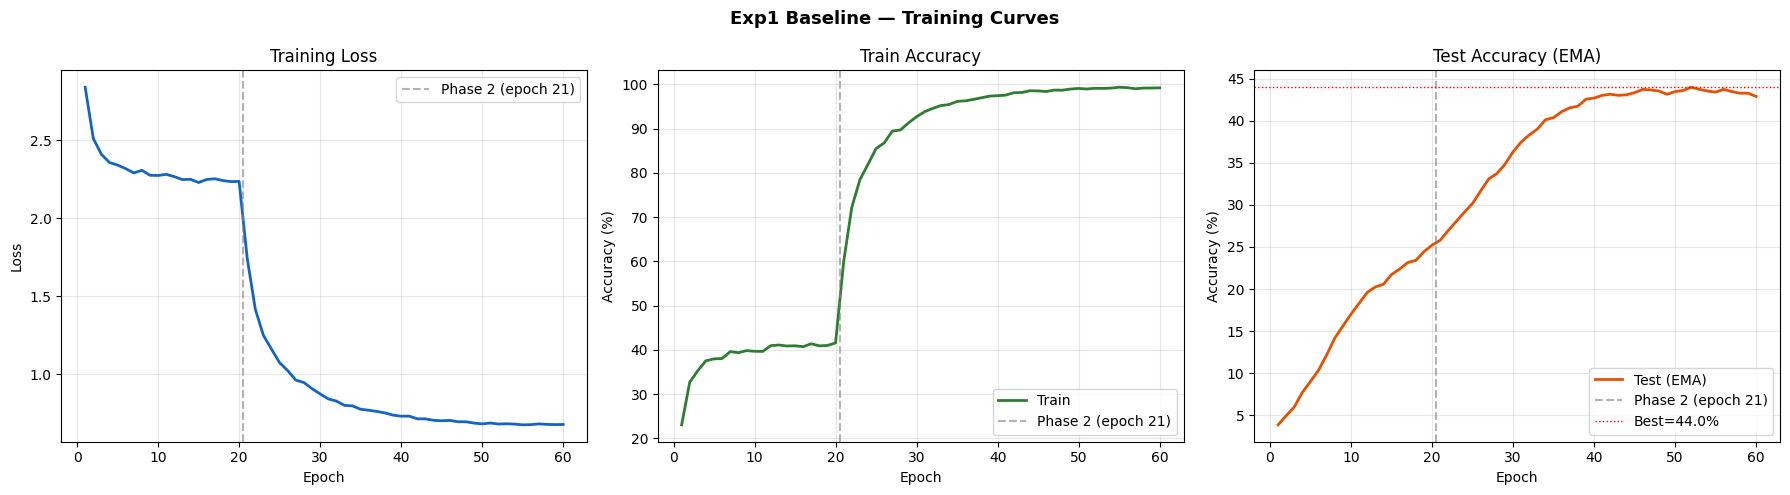

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Exp1 Baseline — Training Curves', fontsize=13, fontweight='bold')
ep = range(1, TOTAL_EPOCHS + 1)
kw = dict(color='gray', linestyle='--', alpha=0.6, label=f'Phase 2 (epoch {PHASE1_EPOCHS+1})')

axes[0].plot(ep, train_losses, '#1565C0', lw=2)
axes[0].axvline(PHASE1_EPOCHS + 0.5, **kw)
axes[0].set(xlabel='Epoch', ylabel='Loss', title='Training Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(ep, train_accs, '#2E7D32', lw=2, label='Train')
axes[1].axvline(PHASE1_EPOCHS + 0.5, **kw)
axes[1].set(xlabel='Epoch', ylabel='Accuracy (%)', title='Train Accuracy')
axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(ep, test_accs, '#E65100', lw=2, label='Test (EMA)')
axes[2].axvline(PHASE1_EPOCHS + 0.5, **kw)
axes[2].axhline(best_acc, color='red', ls=':', lw=1, label=f'Best={best_acc:.1f}%')
axes[2].set(xlabel='Epoch', ylabel='Accuracy (%)', title='Test Accuracy (EMA)')
axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout()
Path(root / 'Dataset/figures').mkdir(parents=True, exist_ok=True)
plt.savefig(root / 'Dataset/figures/exp1_baseline_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 10 — Evaluation (EMA model)

We load the best checkpoint and compute all 6 metrics required by the project spec.
EMA weights are used — smoother than the raw model and consistently give
+0.5 to +1.5% accuracy (Tan & Le, 2021).

In [10]:
model.load_state_dict(torch.load(SAVE_PATH, map_location=DEVICE))
model.eval()

all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for imgs, lbls in test_loader:
        probs = model(imgs.to(DEVICE)).softmax(dim=1).cpu()
        all_preds.extend(probs.argmax(1).numpy())
        all_labels.extend(lbls.numpy())
        all_probs.extend(probs.numpy())

y_pred  = np.array(all_preds)
y_true  = np.array(all_labels)
y_probs = np.array(all_probs)

acc  = (y_pred == y_true).mean() * 100
f1   = f1_score(y_true, y_pred, average='macro') * 100
prec = precision_score(y_true, y_pred, average='macro', zero_division=0) * 100
rec  = recall_score(y_true, y_pred, average='macro', zero_division=0) * 100

y_bin = label_binarize(y_true, classes=list(range(NUM_CLASSES)))
auc   = roc_auc_score(y_bin, y_probs, average='macro', multi_class='ovr') * 100
mAP   = np.mean([
    average_precision_score(y_bin[:, c], y_probs[:, c])
    for c in range(NUM_CLASSES)
]) * 100

print('=' * 50)
print('  Results')
print('=' * 50)
print(f'  Accuracy  : {acc:.2f}%')
print(f'  F1 macro  : {f1:.2f}%')
print(f'  Precision : {prec:.2f}%')
print(f'  Recall    : {rec:.2f}%')
print(f'  AUC macro : {auc:.2f}%')
print(f'  mAP       : {mAP:.2f}%')
print('=' * 50)

  Results
  Accuracy  : 43.97%
  F1 macro  : 41.67%
  Precision : 64.18%
  Recall    : 43.88%
  AUC macro : 94.68%
  mAP       : 60.69%


## 11 — Per-Class Report

Focus on the bottle sub-class block — the hardest cases in WaRP-C.
The 17 bottle subtypes are visually similar and cause most confusion.

In [11]:
df = pd.DataFrame(
    classification_report(
        y_true, y_pred,
        target_names=CLASS_NAMES,
        digits=3,
        output_dict=True,
    )
).T
print(df.to_string())

                         precision    recall  f1-score      support
bottle-blue               0.703704  0.182692  0.290076   104.000000
bottle-blue-full          0.341176  0.674419  0.453125    43.000000
bottle-blue5l             0.928571  0.180556  0.302326    72.000000
bottle-blue5l-full        0.198198  0.916667  0.325926    24.000000
bottle-dark               0.954545  0.442105  0.604317    95.000000
bottle-dark-full          0.528302  0.823529  0.643678    34.000000
bottle-green              1.000000  0.243243  0.391304    74.000000
bottle-green-full         0.310680  0.941176  0.467153    34.000000
bottle-milk               0.417582  0.666667  0.513514    57.000000
bottle-milk-full          0.782609  0.857143  0.818182    21.000000
bottle-multicolor         0.241379  0.250000  0.245614    28.000000
bottle-multicolorv-full   0.666667  0.190476  0.296296    21.000000
bottle-oil                0.379310  0.458333  0.415094    48.000000
bottle-oil-full           0.000000  0.000000  0.

/home/momo/Documents/Semester 2/Applied machine learning/coursework/Waste-Classification/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/momo/Documents/Semester 2/Applied machine learning/coursework/Waste-Classification/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/momo/Documents/Semester 2/Applied machine learning/coursework/Waste-Classification/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: P

## 12 — Confusion Matrix

Normalised by row (recall per class).
Off-diagonal blocks in the bottle sub-types reveal the hardest confusions.

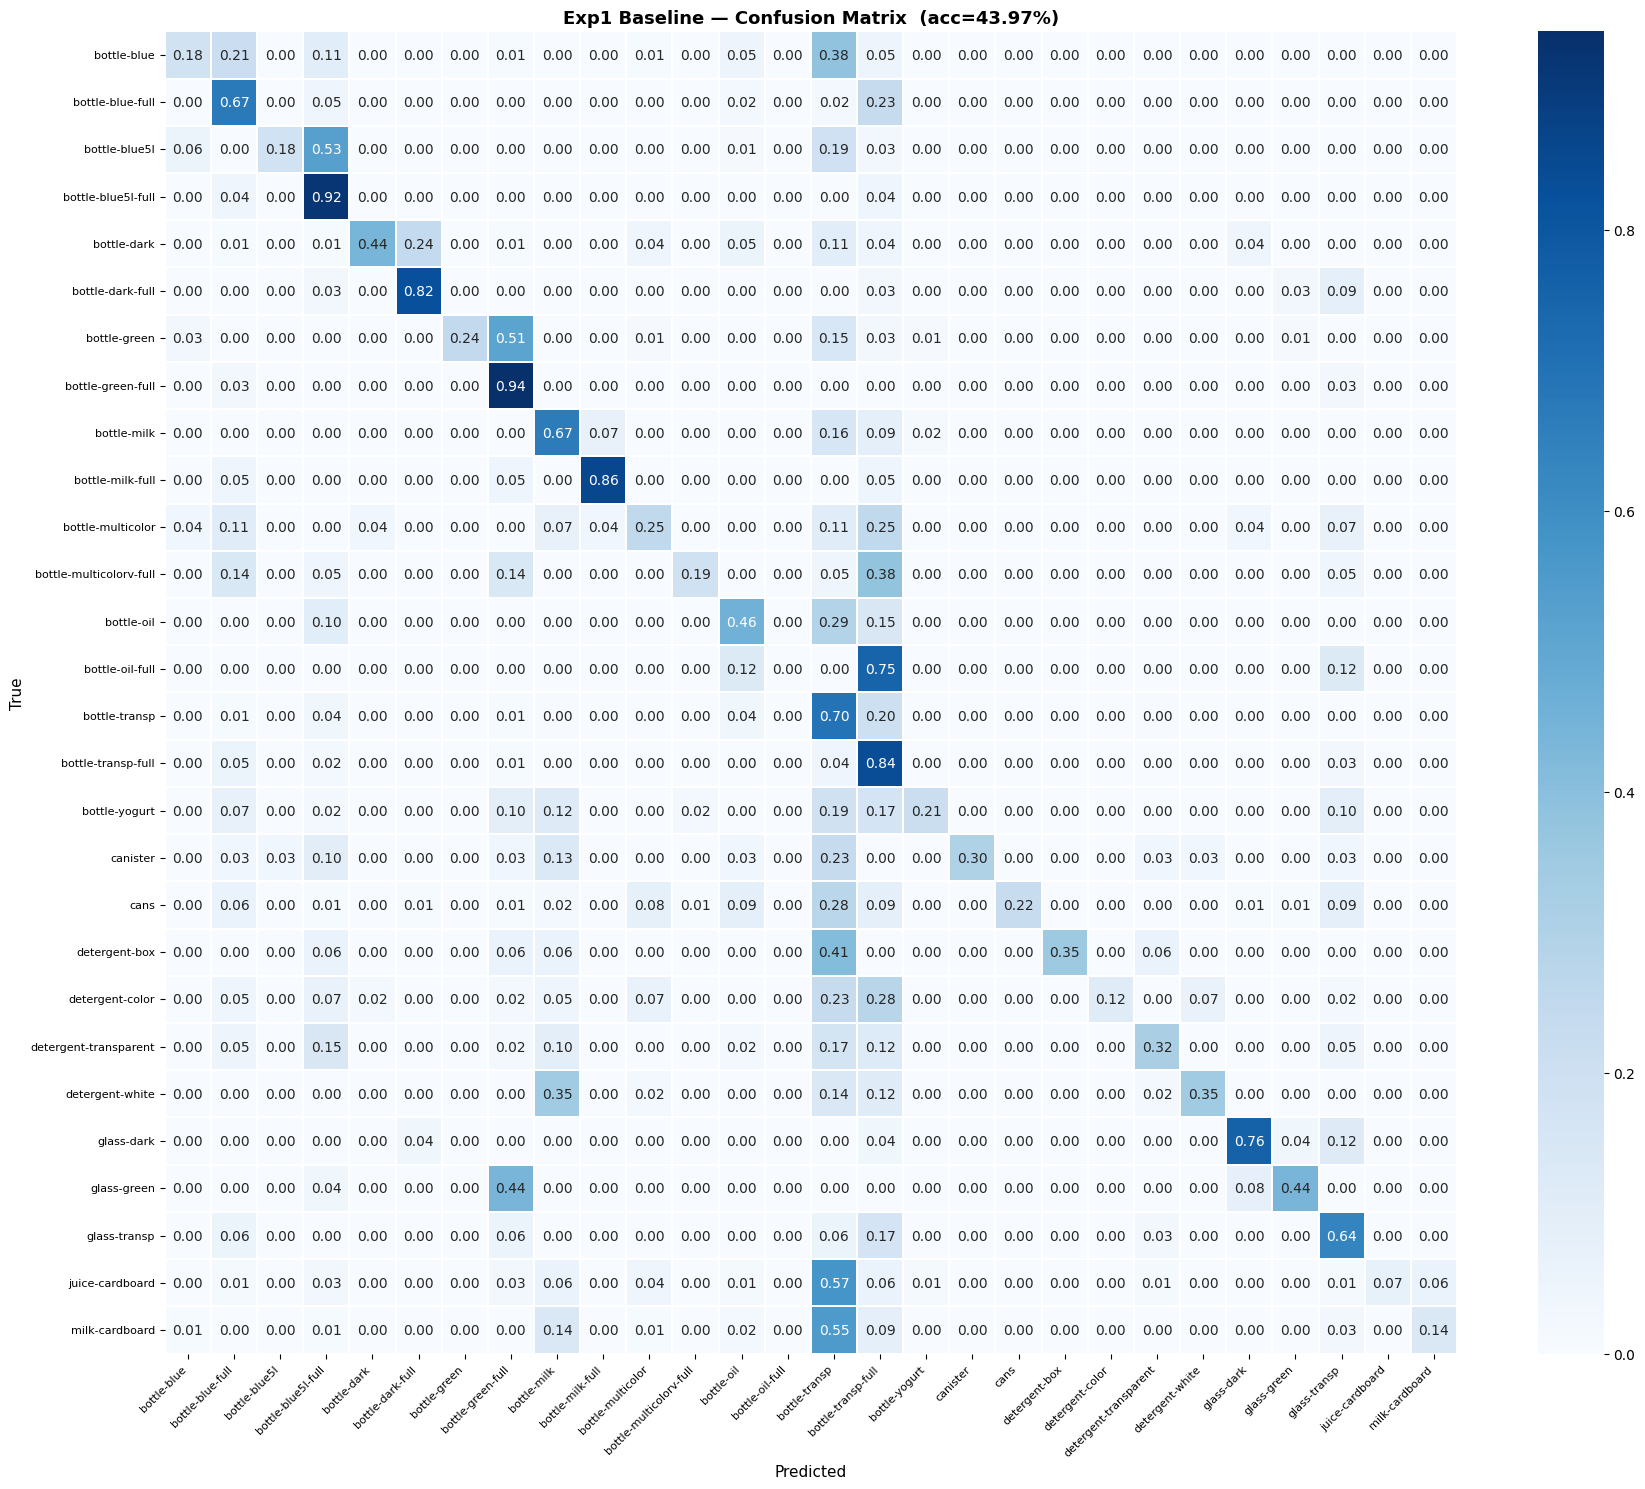

In [12]:
cm      = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(18, 15))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            linewidths=0.3, ax=ax)
ax.set_xlabel('Predicted', fontsize=11)
ax.set_ylabel('True', fontsize=11)
ax.set_title(f'Exp1 Baseline — Confusion Matrix  (acc={acc:.2f}%)', fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig(root / 'Dataset/figures/exp1_baseline_cm.png', dpi=150, bbox_inches='tight')
plt.show()

## 13 — Summary

In [13]:
c = model.parameter_counts()
print('=' * 60)
print('  Exp1 Baseline — Final Summary')
print('=' * 60)
print(f'  Pretrained       : ImageNet-1K  (83.9% top-1)')
print(f'  Total params     : {c["total"]:,}')
print(f'  Phase 1 epochs   : {PHASE1_EPOCHS}  (head only, backbone frozen)')
print(f'  Phase 2 epochs   : {PHASE2_EPOCHS}  (full fine-tuning, diff LR)')
print(f'  Best EMA acc     : {best_acc:.2f}%')
print()
print(f'  Accuracy         : {acc:.2f}%')
print(f'  F1 macro         : {f1:.2f}%')
print(f'  Precision        : {prec:.2f}%')
print(f'  Recall           : {rec:.2f}%')
print(f'  AUC macro        : {auc:.2f}%')
print(f'  mAP              : {mAP:.2f}%')
print('=' * 60)

  Exp1 Baseline — Final Summary
  Pretrained       : ImageNet-1K  (83.9% top-1)
  Total params     : 20,213,356
  Phase 1 epochs   : 20  (head only, backbone frozen)
  Phase 2 epochs   : 40  (full fine-tuning, diff LR)
  Best EMA acc     : 43.97%

  Accuracy         : 43.97%
  F1 macro         : 41.67%
  Precision        : 64.18%
  Recall           : 43.88%
  AUC macro        : 94.68%
  mAP              : 60.69%
